In [1]:
#pip install astroquery

In [1]:
import numpy as np
from astroquery.sdss import SDSS
import pandas as pd
import matplotlib.pyplot as plt
from astroquery.sdss import SDSS

#### Descripción de las diferentes tablas de SDSS survey

https://skyserver.sdss.org/dr12/en/help/docs/tabledesc.aspx

### Cuál es la evolucion QSO? Cantidad de QSO por redshift
Para ello seleccione s.class = 'QSO', y cree un histograma de redshift.
Explique con sus palabras por qué hay mas detecciones de QSO a alto redshift?

Cuántos QSO fueron detectados en un rango de redshift especifico.

In [2]:
query="""
SELECT p.objId,p.ra,p.dec,p.petror90_r, p.g, p.r, s.z

FROM PhotoObj AS p
JOIN SpecObj AS s ON s.bestobjid = p.objid

WHERE s.class = 'QSO'
AND s.z BETWEEN 0.01 AND 1
"""

In [3]:
qso = SDSS.query_sql(query, data_release = 16)
qso

objId,ra,dec,petror90_r,g,r,z
int64,float64,float64,float64,float64,float64,float64
1237645943978656141,55.7186598572598,0.881228331195961,2.106267,21.47115,20.74217,0.5649027
1237645943978918048,56.3129179583576,1.0351042384904,1.762447,19.77899,19.76218,0.5775395
1237646645686763765,71.7252115468675,-1.15289729411323,1.614877,19.94133,19.88161,0.574661
1237648702982324337,219.639544529178,-1.23711622019215,1.447118,17.80097,17.88954,0.5706037
1237648702982979822,221.108515161509,-1.09610626789058,1.342549,19.00111,19.00463,0.5600815
1237648702983963313,223.302260121936,-1.17959612391051,2.253078,22.15474,21.00253,0.5692434
...,...,...,...,...,...,...
1237680529204511503,346.544840017687,28.1459194524356,1.257972,21.96095,21.55156,0.4610094
1237680529207133466,353.289778543837,29.0123949709019,2.279004,23.21311,21.54098,0.5173327


#### ¿Cuántos QSO fueron detectados en un rango de redshift específico?

In [4]:
mask = qso["z"] > 0.8 #hacemos mask para QSO mayores a 0.8
qsohigh = qso[mask]
print("QSO con redshifts mayores a 0.8:", len(qsohigh))

QSO con redshifts mayores a 0.8: 62658


In [5]:
#jugando un poco con el mask
mask = qso["z"] > 0.999995 #hacemos mask para QSO mayores a 0.999995
qsohigh = qso[mask]
print("QSO con redshifts mayores a 0.999995:", len(qsohigh))

QSO con redshifts mayores a 0.999995: 2


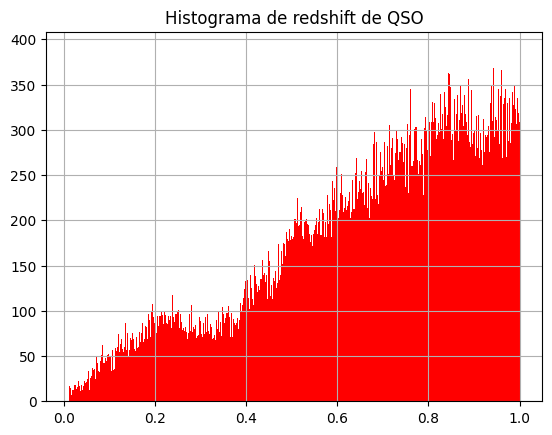

In [6]:
plt.hist(qso["z"], bins=1000, color="red")
plt.title("Histograma de redshift de QSO")
plt.grid("--")
plt.show()

#### ¿Por qué hay mas detecciones de QSO a alto redshift?

**Esto puede deberse principalmente a que existían una gran cantidad de QSO en el universo temprano, además de corresponder a uno de los objetos astronómicos más brillantes que existen, por lo que su luz viaja en distancias y tiempos de escalas cosmológicas.**

#### Qué fracción QSO hay respecto a galaxias normales ?

Para ello selecione s.class = "GALAXY"

Compare con la cantidad de QSO encontrados anteriormente, que fraccion de galaxias corresponden a QSO?

Cree un histograma que contenga ambas tipos de galaxias (activas/QSO) y galaxias normales


In [7]:
query="""
SELECT p.objId,p.ra,p.dec,p.petror90_r, p.g, p.r, s.z

FROM PhotoObj AS p
JOIN SpecObj AS s ON s.bestobjid = p.objid

WHERE s.class = 'GALAXY'
AND s.z BETWEEN 0.01 AND 1
"""

In [8]:
gals = SDSS.query_sql(query, data_release = 16)
gals

objId,ra,dec,petror90_r,g,r,z
int64,float64,float64,float64,float64,float64,float64
1237646798136804903,119.488509447166,0.930346750958672,2.267273,21.55564,20.74338,0.6799743
1237646798136804905,119.491278394296,0.959100057143646,3.107189,21.16984,19.37671,0.3968316
1237646798136805020,119.52094862225,0.853258154588575,3.220677,21.44343,19.67306,0.4120708
1237646798136805140,119.554267199424,0.890822769707441,3.23897,21.24721,19.39289,0.4131401
1237646798136870225,119.582639609107,0.952347067064068,4.49769,20.74059,18.99681,0.3991932
1237646798136934932,119.840030933267,0.952185522532014,6.343918,19.32076,17.81846,0.2538315
...,...,...,...,...,...,...
1237656906345087598,337.170374148734,-0.9142457262461,1.132879,22.42176,22.20058,0.7770037
1237656906345087705,337.212138769475,-0.946885360931512,2.030731,23.52995,21.45278,0.6349074


In [9]:
mask_qso = np.isin(gals["objId"], qso["objId"]) #función que revisa qué Ids se comparten 

qso_gals = gals[mask_qso]

print("Galaxias que son también QSO:", len(qso_gals))

Galaxias que son también QSO: 0


In [10]:
#fracción de QSO respecto a galaxias
galaxias = len(gals)
qsos = len(qso)

fraccion = qsos / galaxias #calculo fracción

print("Total Galaxias:", galaxias)
print(f"Total QSOs", qsos)
print(f"Por cada galaxia normal, hay", fraccion, "QSO.")

Total Galaxias: 500000
Total QSOs 175897
Por cada galaxia normal, hay 0.351794 QSO.


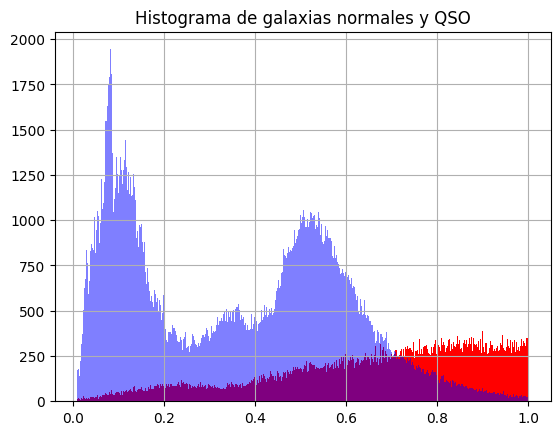

In [12]:
plt.hist(qso["z"], bins=1000, color="red")
plt.hist(gals["z"], bins=1000,alpha = 0.5, color="blue")
plt.title("Histograma de galaxias normales y QSO")
plt.grid("--")
plt.show()

### Ahora busque quasars utilizando el metodo de Gordon Richards  et al. 2002, cuantos quasar es posible encontrar?


From Gordon Richards  et al. 2002 https://ui.adsabs.harvard.edu/abs/2002AJ....123.2945R/abstract

and (u - g >= -0.27)
and (u - g < 0.71)
and (g - r >= -0.24)
and (g - r < 0.35)
and (r - i >= -0.27)
and (r - i < 0.57)
and (i - z >= -0.35)
and (i - z < 0.70) )




In [49]:
query_gr="""
SELECT p.objId,p.ra,p.dec,p.petror90_r, p.g, p.r, p.z, p.u, p.i

FROM PhotoObj AS p
JOIN SpecObj AS s ON s.bestobjid = p.objid
JOIN galSpecLine AS l ON s.specObjId = l.specObjId

WHERE s.class = 'GALAXY'
AND s.z BETWEEN 0.01 AND 1
AND (p.u - p.g >= -0.27) AND (p.u - p.g < 0.71)
AND (p.g - p.r >= -0.24) AND (p.g - p.r < 0.35)
AND (p.r - p.i >= -0.27) AND (p.r - p.i < 0.57)
AND (p.i - p.z >= -0.35) AND (p.i - p.z < 0.70) 


"""

In [50]:
qso_gr = SDSS.query_sql(query_gr, data_release = 16)
qso_gr

objId,ra,dec,petror90_r,g,r,z,u,i
int64,float64,float64,float64,float64,float64,float64,float64,float64
1237651735763550261,195.030050056233,2.00877122732047,2.465295,18.11869,17.89473,17.62321,18.67671,17.6021
1237652900759666803,26.8403506976052,-9.27951928207057,1.98986,19.41443,19.09932,19.32353,19.7302,18.97539
1237654030326693916,167.20229051476,2.77454658716303,5.666234,17.10783,17.05661,16.80795,17.77955,16.80215
1237654382515126431,138.60795392187,53.0761263491277,1.904797,19.40947,19.11153,18.73549,20.03049,18.74076
1237654952668627010,251.740599556038,42.1035809359599,4.796125,17.37371,17.19782,16.93913,18.03493,17.04972
1237654953742893497,253.613980760933,41.5457495883958,2.27299,19.17731,18.85694,18.59738,19.73247,18.55881
...,...,...,...,...,...,...,...,...
1237665226766483525,179.382197413583,32.3416911312884,10.60002,14.61012,14.61102,14.81693,14.87277,14.85735
1237665330380537910,161.848367195774,30.3622991323676,4.199153,15.80519,15.80022,15.63455,16.46214,15.74855


### Para afinar la busqueda, podemos tambine utilizar informacion espectroscopica de la tabla SpecObj, y galSpecLine


Podemos selecionar quasar utilizando el ancho de linea

l.sigma_balmer*2.35482004503

Y la presencia de lineas de emission fuertes, e.g., l.h_gamma_flux, l.h_beta_flux, l.oiii_5007_flux

utlice las siguientes tablas

FROM PhotoObj AS p
JOIN SpecObj AS s ON s.bestobjid = p.objid
JOIN galSpecLine as l ON s.specObjId = l.specObjId


Una vez encuentre estos objetos, plotee el espectro/imagenes en algun filtro de alguno de estos quasares.

In [104]:
query_gr_2="""
SELECT p.objId,p.ra,p.dec,p.petror90_r, p.g, p.r, p.z, p.u, p.i, s.plate,s.fiberid, s.mjd, l.sigma_balmer, l.sigma_balmer, l.h_gamma_flux, l.h_beta_flux

FROM PhotoObj AS p
JOIN SpecObj AS s ON s.bestobjid = p.objid
JOIN galSpecLine AS l ON s.specObjId = l.specObjId

WHERE s.class = 'QSO'
AND s.z BETWEEN 0.01 AND 0.6
AND (p.u - p.g >= -0.27) AND (p.u - p.g < 0.71)
AND (p.g - p.r >= -0.24) AND (p.g - p.r < 0.35)
AND (p.r - p.i >= -0.27) AND (p.r - p.i < 0.57)
AND (p.i - p.z >= -0.35) AND (p.i - p.z < 0.70) 

AND l.h_beta_flux > 2
AND l.oiii_5007_flux > 2
AND l.sigma_balmer*2.35482004503 > 1000

"""

In [105]:
qso_gr_2 = SDSS.query_sql(query_gr_2, data_release = 16)
qso_gr_2

objId,ra,dec,petror90_r,g,r,z,u,i,plate,fiberid,mjd,sigma_balmer,sigma_balmer1,h_gamma_flux,h_beta_flux
int64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64
1237648702992810003,243.501275393886,-1.16835411434285,1.624375,18.58529,18.37602,17.93867,18.62403,18.18464,346,300,51693,500.0,500.0,126.639,210.5464
1237648704050495650,206.965457469585,-0.255118004754507,1.311439,17.85801,18.03603,17.99479,18.11658,17.95682,300,200,51943,500.0,500.0,114.6508,320.477
1237648704050626749,207.163086438603,-0.253182832638073,1.336326,19.19852,19.12582,18.86258,19.73264,18.84694,300,174,51943,500.0,500.0,73.04234,181.7716
1237648721780801569,210.125584114233,0.369039471297535,1.904776,18.2426,17.9499,17.53971,18.40048,17.82025,301,545,51942,500.0,500.0,140.1072,312.2499
1237648721783554162,216.441281324315,0.378537821738933,2.684793,18.82458,18.59554,17.90214,18.90701,18.45602,305,460,51613,500.0,500.0,96.3964,168.062
1237649920044367956,26.5075966073023,14.1971150003753,2.733774,19.00462,18.9827,18.60608,19.36036,18.73119,429,429,51820,500.0,500.0,39.67975,122.265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1237671956980498793,203.493730806355,4.71198148918949,1.946331,19.17215,18.90902,18.49878,19.38362,18.72234,853,433,52374,500.0,500.0,24.85391,68.51254
1237673705582035247,126.785569594912,42.8382908038211,2.596334,18.77024,18.56417,17.95544,18.85387,18.5092,761,420,54524,500.0,500.0,61.80823,167.5757


[[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x743f866566b0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f869b55d0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f878667d0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f87867160>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f866ede40>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f8710a6e0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f8720b760>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f8775e020>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f8775e620>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f8788e350>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f873a84c0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f873c6d70>]]


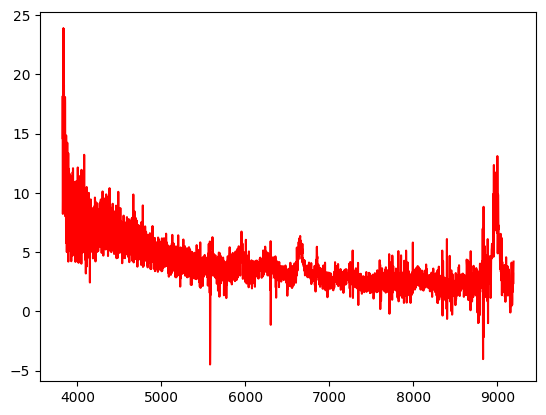

[[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x743f86a2a590>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f880ec5e0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f878668c0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f87866d10>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f866ec5b0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f8710a380>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f86bb4130>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f8775d2a0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f8775f160>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f866551e0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f873a9db0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f873ab100>]]


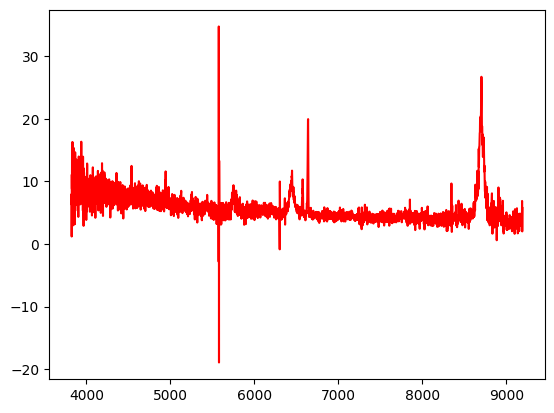

[[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x743f86a6f490>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f87a20100>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f870adf90>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f870ace50>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f878669b0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f87a8b2b0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f8710b760>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f87303370>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f8775e950>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f8775c9d0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f8788e800>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x743f873a8940>]]


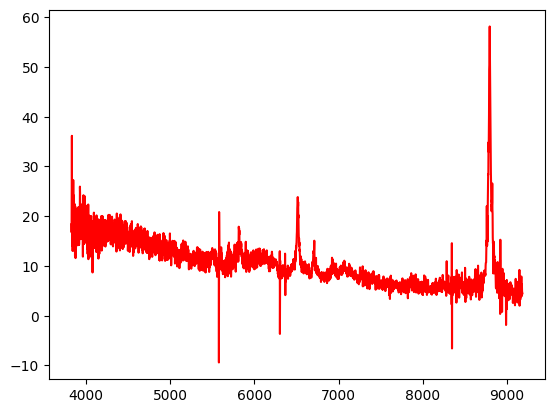

In [103]:
for i in np.arange(0, len(qso_gr_2)):
  plate = np.array(qso_gr_2["plate"][i])
  mjd = np.array(qso_gr_2["mjd"][i])
  fiberID = np.array(qso_gr_2["fiberid"][i])

  sp = SDSS.get_spectra(plate=plate, mjd=mjd, fiberID=fiberID)
  print(sp)
  spectrum_r = sp[0][1]

  plt.plot(10**spectrum_r.data['loglam'], spectrum_r.data['flux'], label='R', c='r')
  plt.plot("Espectro en filtro ")

  plt.show()